<h1 style = "color:red" "align=center"; > Logistic Regression Lecture </h1>

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd

df = pd.read_csv('https://archive.ics.uci.edu/ml/'
        'machine-learning-databases/iris/iris.data', header=None)
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
df.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


<b> Next, extract the first 100 class labels (this corresponds to 50 Iris-Setosa and 50 Iris-Versicolor flowers, respectively)</b>

In [3]:
# select setosa and versicolor 
y = df.iloc[:100, 4].values
print(y)

['Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor

# Class Label Encoding

In [4]:
# use numpy where method to do our class label encoding 
y = np.where(y == 'Iris-setosa', 0, 1)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

To keep the analysis simple, only use two features from the reduced dataset/ I'll extract the first feature column (sepal_length) and the third feature column (petal_length))to use in our analysis 

In [5]:
# Extract sepal_length and petal_Length
X = df.iloc[:100, [0, 2]].values

Now that I have extracted the subset of data 

# Plotting the Iris Data Subset 

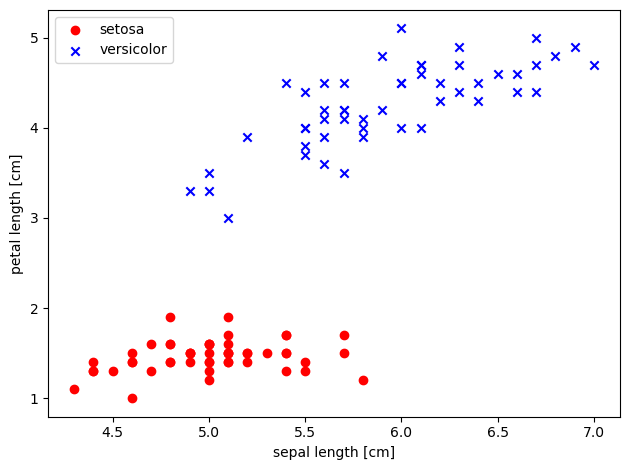

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

#plot data
plt.scatter(X[:50, 0], X[:50, 1],
           color = 'red', marker='o', label='setosa')
plt.scatter(X[50:100, 0], X[50:100, 1],
           color='blue', marker='x', label='versicolor')

plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')

plt.tight_layout()
plt.savefig('Decision_Boundary_Plot.png', dpi=300)
plt.show()


TestTrain Split Of Dataset

Create Testing and Training Datasets

In [7]:
from sklearn.model_selection import train_test_split

#test_size=.20 means the test consists of 20% of the data
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2,random_state=123)

print('Class labels of y_train:', np.unique(y_train))
print('Class proportions of y_train:', np.bincount(y_train))
print('Class proportions of y_test :', np.bincount(y_test))

Class labels of y_train: [0 1]
Class proportions of y_train: [41 39]
Class proportions of y_test : [ 9 11]


# <b> Build(train) the Model</b>

In [8]:
from sklearn.linear_model import LogisticRegression

logr = LogisticRegression(solver='newton-cg',
                       multi_class='multinomial',
                       random_state=0)
logr.fit(X_train, y_train)

LogisticRegression(multi_class='multinomial', random_state=0,
                   solver='newton-cg')

Store the predictions 

In [9]:
y_pred = logr.predict(X_test)
print("Test set predictions:\n {}".format(y_pred))
print('Test accuracy: {0:0.2f}'.format(logr.score(X_test, y_test)))

Test set predictions:
 [0 1 1 0 1 0 0 1 1 0 0 1 1 1 0 0 1 0 1 1]
Test accuracy: 1.00


# Print the probability for the "unknown" belonging to each class

This is called the <i> class membership probability</i>

In [10]:
print()
print('For the arbitray sample with feature values{0}\n'.
      format(np.array(X_test[1:2])))
print('The predicted probability for belonging to the classes[class=0  class=1] are {0}'.
     format(logr.predict_proba(X_test[1:2])))
print('\nThe sum of the columns is {}'.format(logr.predict_proba(X_test[1:2]).sum(axis=1)))


For the arbitray sample with feature values[[5.9 4.8]]

The predicted probability for belonging to the classes[class=0  class=1] are [[9.02235345e-04 9.99097765e-01]]

The sum of the columns is [1.]


Note that the class=1 (Iris-versicolor) has the the highest probability (0.999) out of the results 

# <b> Extract the Model Coefficients and Build a Model</b>

In [11]:
print('The coefficients from logistic regression are  {}'.format(logr.coef_))
print('The intercept from logistic regression is  {}'.format(logr.intercept_))
#logr.intercept

The coefficients from logistic regression are  [[0.14899442 1.607505  ]]
The intercept from logistic regression is  [-5.09022485]


> <b> Note that the logistic regression fit returns the coefficients and intercepts as arrays</b>
 
> <b> (2D for coefficients and 1D for the intercept)</b>

In [12]:
coefs=logr.coef_[0]

intercept = logr.intercept_
print('The coefficient of the feature sepal_length is {}'.format(coefs[0]))
print('The coefficient of the feature petal_length is {}'.format(coefs[1]))
print('The intercept has the value of is {}'.format(intercept[0]))

The coefficient of the feature sepal_length is 0.14899442315286532
The coefficient of the feature petal_length is 1.607505002193139
The intercept has the value of is -5.090224849742398


# <b>Build the model equation and use it to test with unknown species</b>

The model equation is: 

In [13]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

<h2 style = "color:orange" "align=center"; > A simple way is to just use the model equation and sigmoid function </h2>

In [14]:
# 1 = Versicolor and 0 = Setosa
sepal_length, petal_length = 5.1, 1.4  #Iris Setosa
z = 0.149*sepal_length  + 1.60*petal_length - 5.09
print('The sigmoid function at this z is {0:.2f} and thus the probability rounds to {1:0.1f}'
     .format(sigmoid(z),round(sigmoid(z))))

The sigmoid function at this z is 0.11 and thus the probability rounds to 0.0


This represents that the sigmoid function (logistic function) predicts that the flower belongs to class=0 which is Setosa

In [15]:
# 1 = Versicolor and 0 = Setosa
sepal_length, petal_length = 5.1, 1.4  #Iris Setosa 
z = 0.149*sepal_length + 1.60*petal_length - 5.09
print('class membership probabilities',logr.predict_proba([[sepal_length, petal_length]]))
print(logr.predict_proba([[sepal_length, petal_length]]).sum(axis=1))  #(axis = 1) means sum row

class membership probabilities [[0.98462764 0.01537236]]
[1.]


Which means that the model predicts the probability of 98.5% that the flower is class=0 (Setosa) and 1.5% probability that is class=1 (Versicolor) is consistent with the logistic function 

<h2 style = "color:orange" "align=center"; > A bit more <i> sophisticated</i> is to just use the model's coefficients with numpy </h2>

In [16]:
# 1 = Versicolor and 0 = Setosa
sepal_length, petal_length = 5.1, 1.4  #Iris Setosa

z = np.dot(np.array([sepal_length, petal_length]), np.array(logr.coef_[0])) +logr.intercept_[0]
print('z= wx + b =  {0:.3f}\n'.format(z))

p = sigmoid(np.dot([sepal_length, petal_length], logr.coef_[0]) +logr.intercept_[0])

print('The true class is {0:1d} and the predicted class is {1:.3f} which rounds to {2:.0f}'.format(0,p,round(p,0)))

z= wx + b =  -2.080

The true class is 0 and the predicted class is 0.111 which rounds to 0


<h1 style = "color:green" "align=center"; > Summary </h1>

We have demonstrated how to build machine learning models based on the logistic regression algorithm. We fitted the model to a subset of the iris dataset and built a model equation I used to classify unknown flowers. I also demonstrated how to extract class-membership probabilities and use them in my predicitive analytics.

<h1 style = "color:green" "align=center"; > Addendum-Classification Report and Confusino Matrix </h1>

<h3> Model's Performance Evaluation via the Classification Report and the Confusion Matrix</h3>

Her I determin how well the model I built works by applying model evaluation metrics (i.e. printing the classification report and the confusion matrix. Note, you have to import as follows to use the metrics: <mark> from sklearn import metrics</mark>

In [17]:
from sklearn import metrics 
print ("Classification Report:")
print (metrics.classification_report(y_test, y_pred, target_names = ['setosa','versicolor']))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         9
  versicolor       1.00      1.00      1.00        11

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



### Confusion Matrix

In [18]:
print("Confusion Matrix:")
print (metrics.confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[ 9  0]
 [ 0 11]]


<h1 style = "color:green" "align=center"; > Addendum II-<i> Pretty</i> Confusion Matrix </h1>

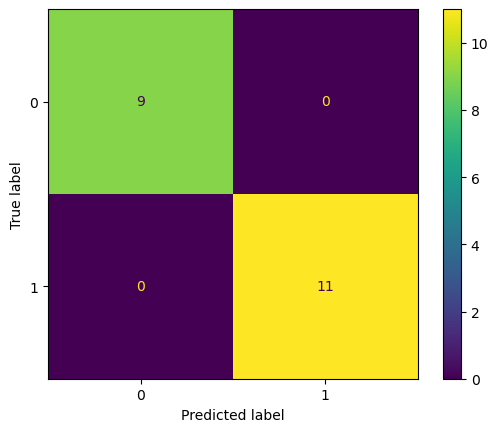

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred, labels=logr.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=logr.classes_)
disp.plot()

plt.show()